<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 171.2 MB/s eta 0:00:00


In [2]:
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 146.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 157.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 168.2 MB/s eta 0:00:00


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-01-14 06:53:22--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  65.0MB/s    in 2.3s    

2026-01-14 06:53:24 (65.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [12]:
column_list = list(df.columns)
column_list.sort()
column_list

['AIAcc',
 'AIBen',
 'AIChallenges',
 'AIComplex',
 'AIEthics',
 'AINextLess integrated',
 'AINextMore integrated',
 'AINextMuch less integrated',
 'AINextMuch more integrated',
 'AINextNo change',
 'AISearchDevAdmired',
 'AISearchDevHaveWorkedWith',
 'AISearchDevWantToWorkWith',
 'AISelect',
 'AISent',
 'AIThreat',
 'AIToolCurrently Using',
 'AIToolInterested in Using',
 'AIToolNot interested in Using',
 'Age',
 'BuildvsBuy',
 'BuyNewTool',
 'Check',
 'CodingActivities',
 'CompTotal',
 'ConvertedCompYearly',
 'Country',
 'Currency',
 'DatabaseAdmired',
 'DatabaseHaveWorkedWith',
 'DatabaseWantToWorkWith',
 'DevType',
 'EdLevel',
 'EmbeddedAdmired',
 'EmbeddedHaveWorkedWith',
 'EmbeddedWantToWorkWith',
 'Employment',
 'Frequency_1',
 'Frequency_2',
 'Frequency_3',
 'Frustration',
 'ICorPM',
 'Industry',
 'JobSat',
 'JobSatPoints_1',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 

### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



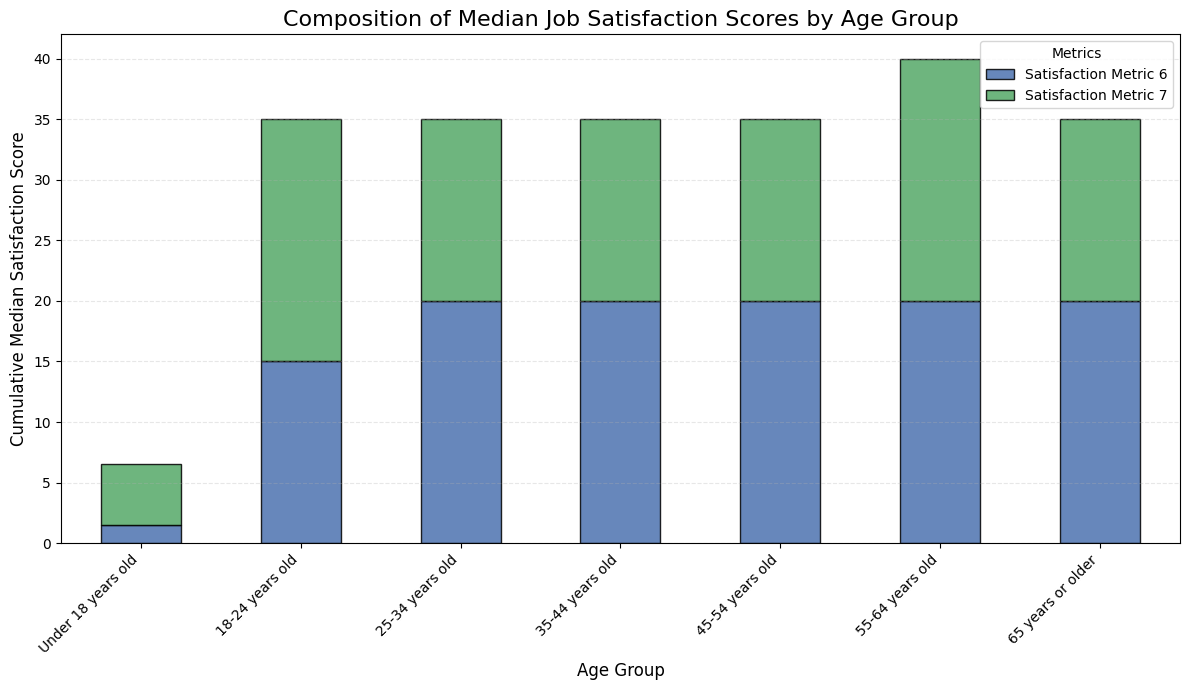

Median Satisfaction Scores by Age Group:
                    JobSatPoints_6  JobSatPoints_7
Age                                               
Under 18 years old             1.5             5.0
18-24 years old               15.0            20.0
25-34 years old               20.0            15.0
35-44 years old               20.0            15.0
45-54 years old               20.0            15.0
55-64 years old               20.0            20.0
65 years or older             20.0            15.0


In [10]:
##Write your code here
# 1. Prepare the Data
# Ensure satisfaction scores are numeric
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['JobSatPoints_7'] = pd.to_numeric(df['JobSatPoints_7'], errors='coerce')

# Define the logical chronological order for Age groups
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]

# 2. Aggregation
# Group by Age and calculate the median for both satisfaction columns
# We use .reindex() to ensure the age groups appear in the correct order
age_satisfaction_medians = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().reindex(age_order)

# 3. Create the Stacked Bar Chart
plt.figure(figsize=(12, 7))

# Plotting directly from the grouped DataFrame
age_satisfaction_medians.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(), 
    color=['#4c72b0', '#55a868'],
    alpha=0.85,
    edgecolor='black'
)

# 4. Formatting and Labels
plt.title('Composition of Median Job Satisfaction Scores by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Cumulative Median Satisfaction Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Satisfaction Metric 6', 'Satisfaction Metric 7'], title='Metrics', loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the table for reference
print("Median Satisfaction Scores by Age Group:")
print(age_satisfaction_medians)

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


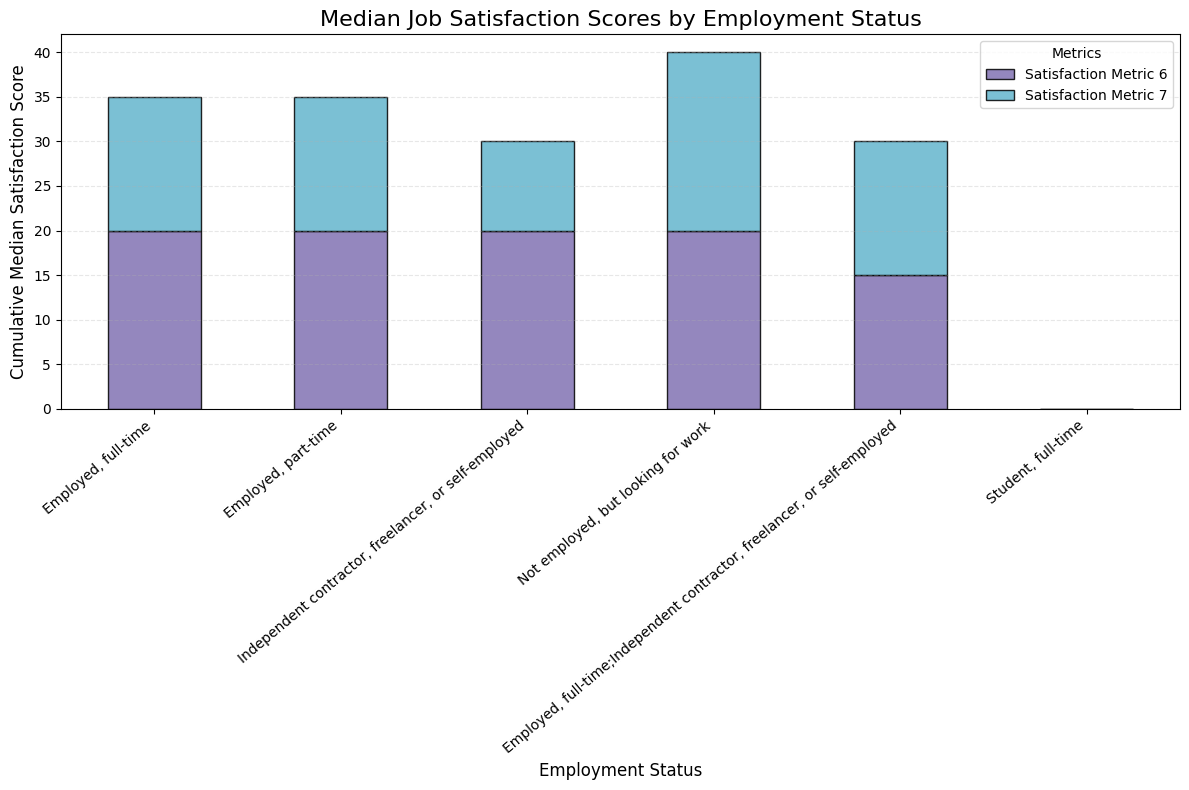

Median Satisfaction Scores by Top Employment Types:
                                                    JobSatPoints_6  \
Employment                                                           
Employed, full-time                                           20.0   
Employed, part-time                                           20.0   
Independent contractor, freelancer, or self-emp...            20.0   
Not employed, but looking for work                            20.0   
Employed, full-time;Independent contractor, fre...            15.0   
Student, full-time                                             NaN   

                                                    JobSatPoints_7  
Employment                                                          
Employed, full-time                                           15.0  
Employed, part-time                                           15.0  
Independent contractor, freelancer, or self-emp...            10.0  
Not employed, but looking for work        

In [14]:
##Write your code here

# 1. Prepare the Data
# Ensure satisfaction scores are numeric for median calculation
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['JobSatPoints_7'] = pd.to_numeric(df['JobSatPoints_7'], errors='coerce')

# 2. Aggregation by Employment Status
# We first identify the most common employment categories to keep the plot clean
top_employment_types = df['Employment'].value_counts().nlargest(6).index
df_filtered = df[df['Employment'].isin(top_employment_types)]

# Group by Employment and calculate the median for both satisfaction columns
# We sort by the first metric to give the chart a logical flow
employment_satisfaction = df_filtered.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()
employment_satisfaction = employment_satisfaction.sort_values(by='JobSatPoints_6', ascending=False)

# 3. Create the Stacked Bar Chart
plt.figure(figsize=(12, 8))

# Plotting directly from the grouped DataFrame
employment_satisfaction.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(), 
    color=['#8172b3', '#64b5cd'], # Different color palette for Employment analysis
    alpha=0.85,
    edgecolor='black'
)

# 4. Formatting and Labels
plt.title('Median Job Satisfaction Scores by Employment Status', fontsize=16)
plt.xlabel('Employment Status', fontsize=12)
plt.ylabel('Cumulative Median Satisfaction Score', fontsize=12)

# Employment strings can be very long, so we use a steep rotation and horizontal alignment
plt.xticks(rotation=40, ha='right')
plt.legend(['Satisfaction Metric 6', 'Satisfaction Metric 7'], title='Metrics', loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the table for reference
print("Median Satisfaction Scores by Top Employment Types:")
print(employment_satisfaction)

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


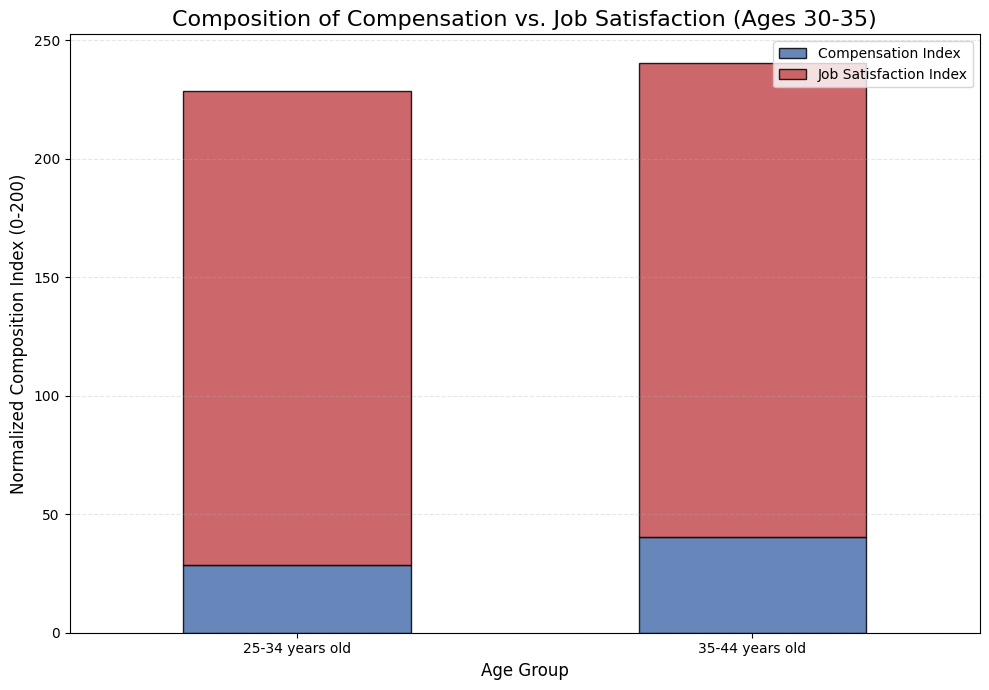

Median Normalized Indices for 30-35 Demographic:
                 Comp_Index  Sat_Index
Age                                   
25-34 years old   28.624402      200.0
35-44 years old   40.572249      200.0


In [15]:
##Write your code here
# 1. Prepare and Normalize the Data
# Ensure compensation and job satisfaction are numeric types
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Filter specifically for the 30-35 age range proxy
# (In the survey, this spans the '25-34 years old' and '35-44 years old' categories)
target_age_groups = ['25-34 years old', '35-44 years old']
df_target = df[df['Age'].isin(target_age_groups)].copy()

# To create a meaningful "Stacked" chart with different units (USD vs Score), 
# we normalize both metrics to a 0-100 index scale.
# For Compensation, we scale against the 95th percentile to avoid outlier distortion.
comp_limit = df_target['ConvertedCompYearly'].quantile(0.95)
df_target['Comp_Index'] = (df_target['ConvertedCompYearly'] / comp_limit) * 100
# For Satisfaction, we assume a max score of 10.
df_target['Sat_Index'] = (df_target['JobSatPoints_6'] / 10) * 100

# 2. Aggregation
# Calculate the median index scores for these age groups
age_composition = df_target.groupby('Age')[['Comp_Index', 'Sat_Index']].median()

# 3. Create the Stacked Bar Chart
plt.figure(figsize=(10, 7))

age_composition.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(), 
    color=['#4c72b0', '#c44e52'], # Blue for Comp, Red for Satisfaction
    alpha=0.85,
    edgecolor='black'
)

# 4. Formatting and Labels
plt.title('Composition of Compensation vs. Job Satisfaction (Ages 30-35)', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Normalized Composition Index (0-200)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Compensation Index', 'Job Satisfaction Index'], loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table for context
print("Median Normalized Indices for 30-35 Demographic:")
print(age_composition)

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


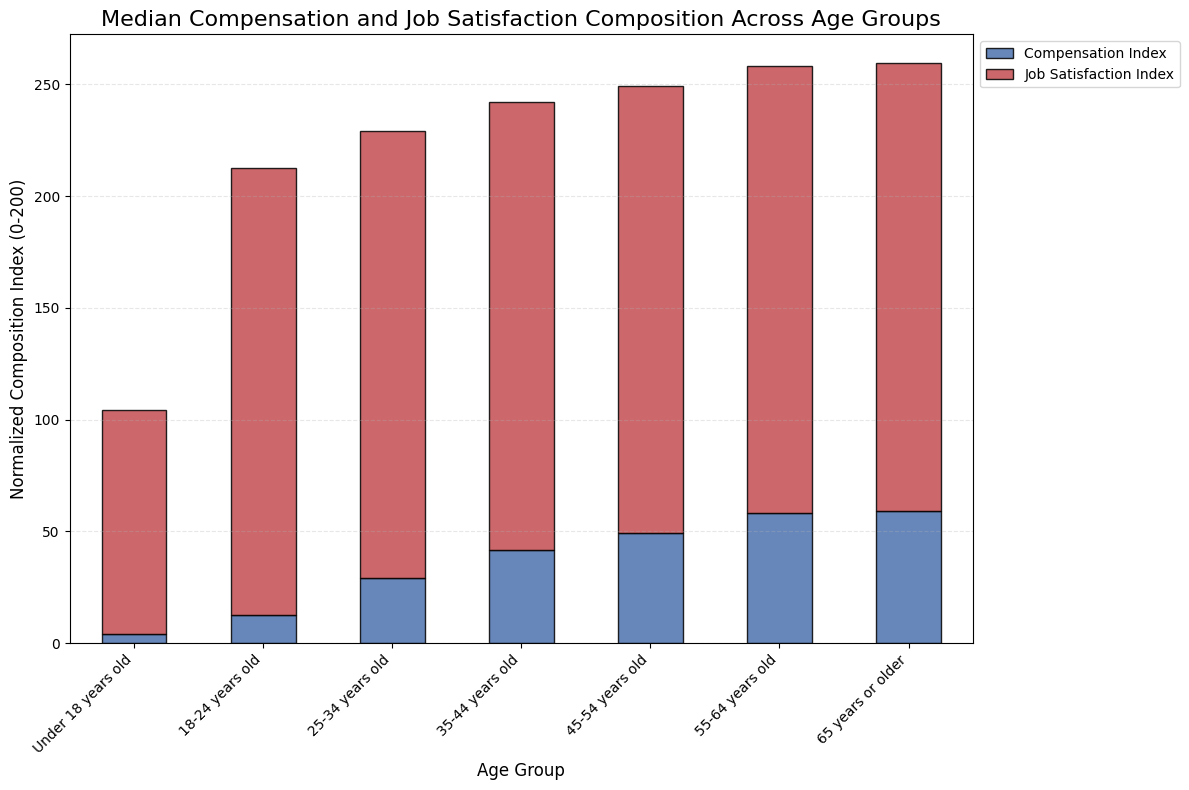

Median Normalized Indices by Age Group:
                    Comp_Index  Sat_Index
Age                                      
Under 18 years old    4.224878      100.0
18-24 years old      12.553659      200.0
25-34 years old      29.205854      200.0
35-44 years old      41.914634      200.0
45-54 years old      49.219756      200.0
55-64 years old      58.141220      200.0
65 years or older    59.350244      200.0


In [16]:
##Write your code here

# 1. Prepare and Normalize the Data
# Ensure compensation and job satisfaction are numeric types
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Define the logical chronological order for Age groups
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]

# Create a copy for analysis and remove rows with missing critical data
df_clean = df.dropna(subset=['Age', 'ConvertedCompYearly', 'JobSatPoints_6']).copy()

# To create a meaningful "Stacked" chart with different units (USD vs Score), 
# we normalize both metrics to a 0-100 index scale across the entire dataset.
# For Compensation, we scale against the 95th percentile to avoid outlier distortion.
comp_limit = df_clean['ConvertedCompYearly'].quantile(0.95)
df_clean['Comp_Index'] = (df_clean['ConvertedCompYearly'] / comp_limit) * 100
# For Satisfaction, we assume a max score of 10.
df_clean['Sat_Index'] = (df_clean['JobSatPoints_6'] / 10) * 100

# 2. Aggregation
# Calculate the median index scores per age group and reindex to chronological order
age_composition = df_clean.groupby('Age')[['Comp_Index', 'Sat_Index']].median().reindex(age_order)

# Remove any age groups that might not have data after filtering
age_composition = age_composition.dropna()

# 3. Create the Stacked Bar Chart
plt.figure(figsize=(12, 8))

age_composition.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(), 
    color=['#4c72b0', '#c44e52'], # Blue for Comp, Red for Satisfaction
    alpha=0.85,
    edgecolor='black'
)

# 4. Formatting and Labels
plt.title('Median Compensation and Job Satisfaction Composition Across Age Groups', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Normalized Composition Index (0-200)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Compensation Index', 'Job Satisfaction Index'], loc='upper left', bbox_to_anchor=(1, 1))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table for context
print("Median Normalized Indices by Age Group:")
print(age_composition)

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


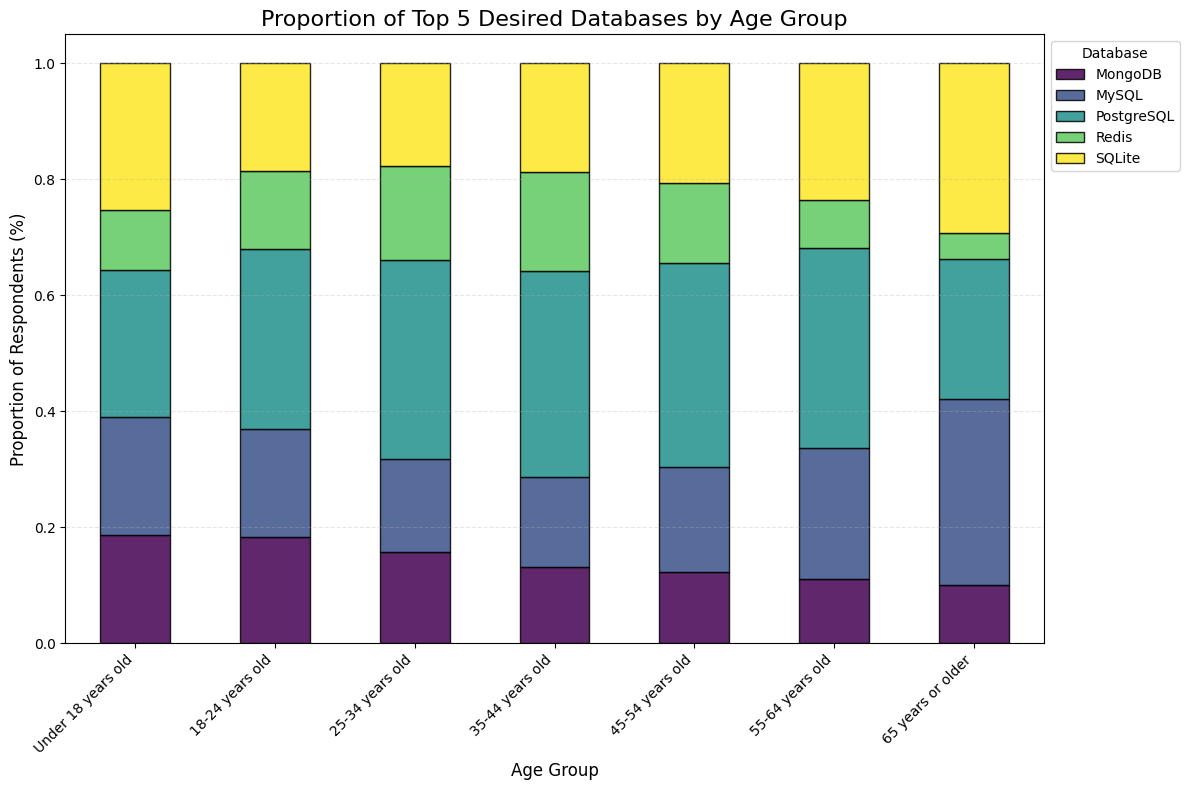

Proportions of Desired Databases by Age Group:
Database            MongoDB  MySQL  PostgreSQL  Redis  SQLite
Age                                                          
Under 18 years old    18.63  20.47       25.20  10.41   25.30
18-24 years old       18.34  18.64       30.98  13.54   18.49
25-34 years old       15.70  16.07       34.27  16.34   17.62
35-44 years old       13.14  15.57       35.43  17.07   18.79
45-54 years old       12.35  17.98       35.18  13.82   20.66
55-64 years old       11.15  22.45       34.51   8.39   23.50
65 years or older     10.07  31.99       24.16   4.47   29.31


In [17]:
##Write your code here

# 1. Prepare Age Data
# Define the logical chronological order for Age groups
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]

# 2. Process Multi-select Databases
# Focus on rows that have both Age and Database preferences
df_clean = df.dropna(subset=['Age', 'DatabaseWantToWorkWith']).copy()

# Split the semicolon-separated strings and explode into individual rows
df_clean['Database'] = df_clean['DatabaseWantToWorkWith'].str.split(';')
df_exploded = df_clean.explode('Database')

# 3. Identify Top 5 Databases Globally
# We filter for the top 5 to ensure the stacked chart remains readable
top_5_dbs = df_exploded['Database'].value_counts().nlargest(5).index
df_top_dbs = df_exploded[df_exploded['Database'].isin(top_5_dbs)]

# 4. Aggregate and Calculate Proportions
# Create a cross-tabulation of Age vs Database
db_age_counts = pd.crosstab(df_top_dbs['Age'], df_top_dbs['Database'])

# Reorder the index to match chronological age
db_age_counts = db_age_counts.reindex(age_order).dropna()

# Normalize by row to get the "proportion" within each age group
# This ensures each bar sums to 1.0 (100%)
db_age_proportions = db_age_counts.div(db_age_counts.sum(axis=1), axis=0)

# 5. Create the Stacked Bar Chart
plt.figure(figsize=(12, 8))

db_age_proportions.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(), 
    colormap='viridis', 
    alpha=0.85,
    edgecolor='black'
)

# 6. Formatting and Labels
plt.title('Proportion of Top 5 Desired Databases by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Proportion of Respondents (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Database', loc='upper left', bbox_to_anchor=(1, 1))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table for context
print("Proportions of Desired Databases by Age Group:")
print((db_age_proportions * 100).round(2))

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


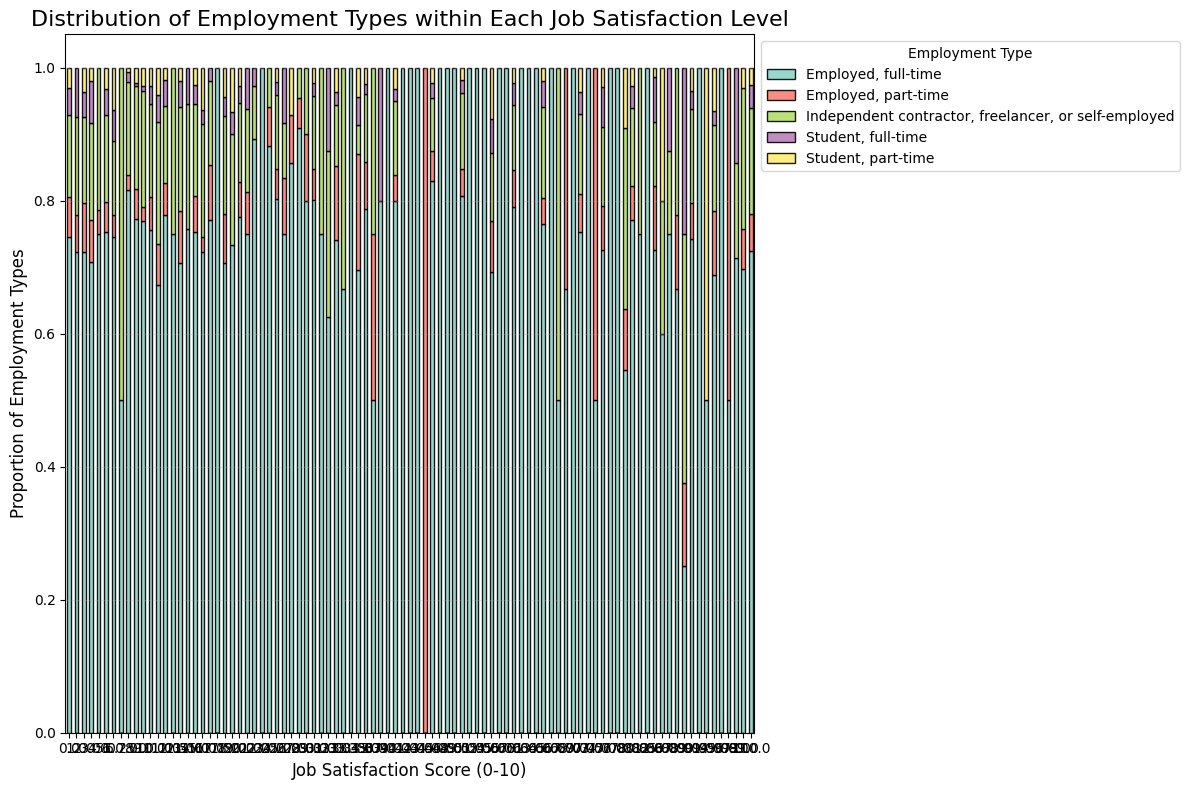

Proportion of Employment Types per Satisfaction Level:
Employment_Type  Employed, full-time  Employed, part-time  \
JobSatPoints_6                                              
0.0                            74.52                 6.07   
1.0                            72.22                 5.56   
2.0                            72.22                 7.41   
3.0                            70.83                 6.25   
4.0                            75.00                 3.57   
...                              ...                  ...   
96.0                          100.00                 0.00   
97.0                           50.00                50.00   
98.0                           71.43                 0.00   
99.0                           69.70                 6.06   
100.0                          72.48                 5.52   

Employment_Type  Independent contractor, freelancer, or self-employed  \
JobSatPoints_6                                                          
0.0  

In [18]:
##Write your code here

# 1. Prepare Job Satisfaction Data
# Ensure the satisfaction score (JobSatPoints_6) is numeric
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# 2. Process Multi-select Employment Column
# Focus on rows that have both Satisfaction and Employment data
df_clean = df.dropna(subset=['JobSatPoints_6', 'Employment']).copy()

# Split the semicolon-separated employment strings and explode into individual rows
df_clean['Employment_Type'] = df_clean['Employment'].str.split(';')
df_exploded = df_clean.explode('Employment_Type')

# 3. Identify Top Employment Types
# To keep the chart readable, we filter for the most common employment categories
top_employment_types = df_exploded['Employment_Type'].value_counts().nlargest(5).index
df_top_employment = df_exploded[df_exploded['Employment_Type'].isin(top_employment_types)]

# 4. Aggregate and Calculate Proportions
# Create a cross-tabulation of Satisfaction Score vs. Employment Type
# Rows = Satisfaction Level, Columns = Employment Types
sat_emp_counts = pd.crosstab(df_top_employment['JobSatPoints_6'], df_top_employment['Employment_Type'])

# Normalize by row to get the "proportion" of employment types within each satisfaction level
# This allows us to see the composition of workers at each rating
sat_emp_proportions = sat_emp_counts.div(sat_emp_counts.sum(axis=1), axis=0)

# 5. Create the Stacked Bar Chart
plt.figure(figsize=(12, 8))

sat_emp_proportions.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(), 
    colormap='Set3', # Using a distinct categorical palette
    alpha=0.9,
    edgecolor='black'
)

# 6. Formatting and Labels
plt.title('Distribution of Employment Types within Each Job Satisfaction Level', fontsize=16)
plt.xlabel('Job Satisfaction Score (0-10)', fontsize=12)
plt.ylabel('Proportion of Employment Types', fontsize=12)
plt.xticks(rotation=0) # Keep satisfaction scores horizontal
plt.legend(title='Employment Type', loc='upper left', bbox_to_anchor=(1, 1))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table for context
print("Proportion of Employment Types per Satisfaction Level:")
print((sat_emp_proportions * 100).round(2))

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


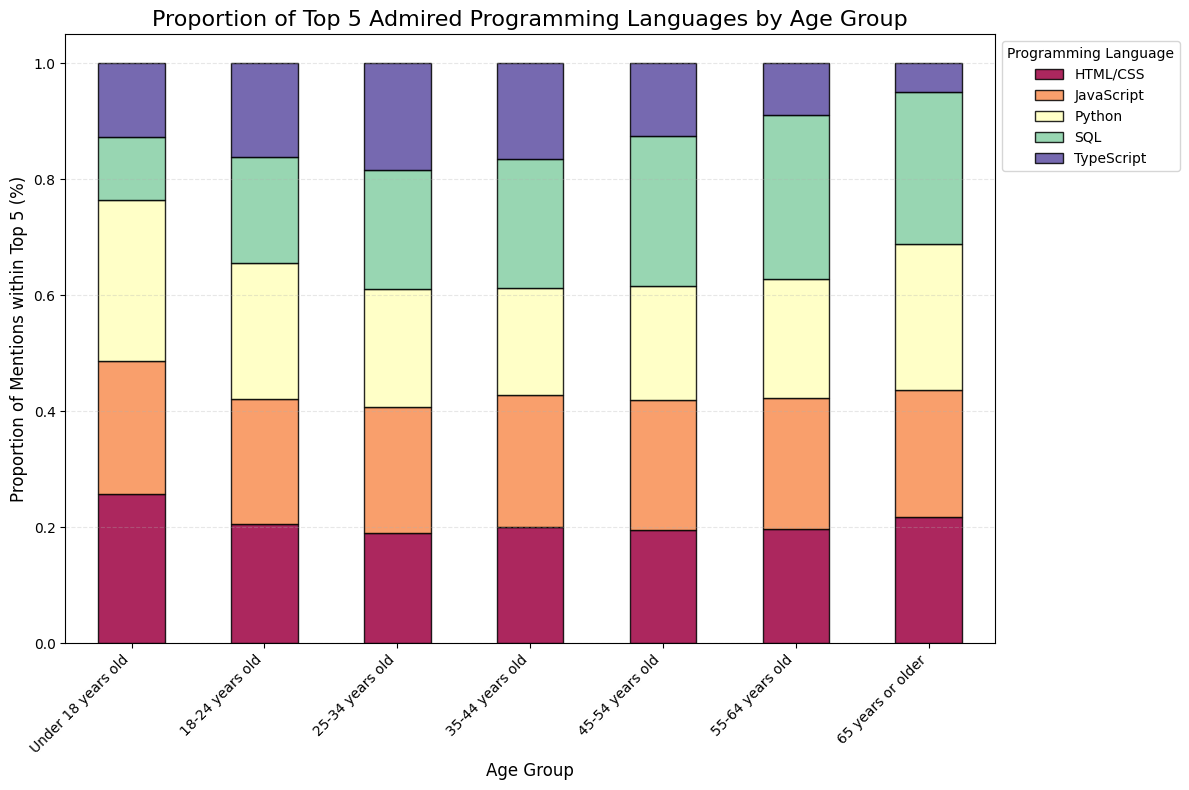

Proportions of Admired Languages by Age Group (%):
Language            HTML/CSS  JavaScript  Python    SQL  TypeScript
Age                                                                
Under 18 years old     25.76       22.98   27.63  11.00       12.63
18-24 years old        20.58       21.51   23.46  18.22       16.23
25-34 years old        19.00       21.73   20.35  20.58       18.34
35-44 years old        20.09       22.63   18.59  22.17       16.52
45-54 years old        19.61       22.34   19.63  25.94       12.48
55-64 years old        19.74       22.61   20.45  28.37        8.83
65 years or older      21.81       21.94   25.03  26.32        4.90


In [19]:
##Write your code here

# 1. Prepare Age Data
# Define the logical chronological order for Age groups to ensure the X-axis is intuitive
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]

# 2. Process Multi-select Admired Languages
# We focus on rows that have both Age and Language admiration data
df_clean = df.dropna(subset=['Age', 'LanguageAdmired']).copy()

# Split the semicolon-separated strings (e.g., "Rust;TypeScript;Python") 
# and explode into individual rows so each language is counted for each respondent
df_clean['Language'] = df_clean['LanguageAdmired'].str.split(';')
df_exploded = df_clean.explode('Language')

# 3. Identify Top 5 Most Admired Languages Overall
# We filter for the top 5 to ensure the stacked chart remains readable
top_5_langs = df_exploded['Language'].value_counts().nlargest(5).index
df_top_langs = df_exploded[df_exploded['Language'].isin(top_5_langs)]

# 4. Aggregate and Calculate Proportions
# Create a cross-tabulation of Age vs. Admired Language
lang_age_counts = pd.crosstab(df_top_langs['Age'], df_top_langs['Language'])

# Reorder the index to match chronological age and drop empty categories
lang_age_counts = lang_age_counts.reindex(age_order).dropna()

# Normalize by row to get the "proportion" within each age group
# This shows the percentage of "Top 5" votes each language gets in that bracket
lang_age_proportions = lang_age_counts.div(lang_age_counts.sum(axis=1), axis=0)

# 5. Create the Stacked Bar Chart
plt.figure(figsize=(12, 8))

lang_age_proportions.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(), 
    colormap='Spectral', # Using a vibrant palette to distinguish languages
    alpha=0.85,
    edgecolor='black'
)

# 6. Formatting and Labels
plt.title('Proportion of Top 5 Admired Programming Languages by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Proportion of Mentions within Top 5 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Programming Language', loc='upper left', bbox_to_anchor=(1, 1))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table for context
print("Proportions of Admired Languages by Age Group (%):")
print((lang_age_proportions * 100).round(2))

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [ ]:
##Write your code here

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
